
# CNN for Street View House Number Classification with Layer Visualizations

This notebook trains a small CNN on the SVHN (Street View House Number) dataset. The dataset contains over 600k real-world images of house numbers from Google Street View images.  

We want to take a glimpse into the CNN internals and visualize the feature maps after the first and second convolution layer, as well as the learned filter weights.

It may prove useful to speed up your training time by using a GPU. CUDA is a parallel computing platform and CUDA Tensors are the same as typical Tensors, only they utilize GPU's for computation.

In [1]:
# import necessary libraries
import os, random, math
import numpy as np
import torch
from torch import nn, optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, utils as vutils
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Check for GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


Using device: cuda


## Data Loading and Preprocessing

In [2]:
# Data loading and normalization for SVHN
transform_train = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4377, 0.4438, 0.4728],
                         std=[0.1980, 0.2010, 0.1970])
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4377, 0.4438, 0.4728],
                         std=[0.1980, 0.2010, 0.1970])
])

train_set = datasets.SVHN(root='./data', split='train', download=True, transform=transform_train)
valid_set  = datasets.SVHN(root='./data', split='test',  download=True, transform=transform_test)

batch_size = 128
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=0)
valid_loader  = DataLoader(valid_set,  batch_size=batch_size, shuffle=False, num_workers=0)
len(train_set), len(valid_set)

100%|██████████| 182M/182M [00:08<00:00, 20.7MB/s] 


100%|██████████| 64.3M/64.3M [00:04<00:00, 14.5MB/s]


(73257, 26032)

Let's take a look at some images:

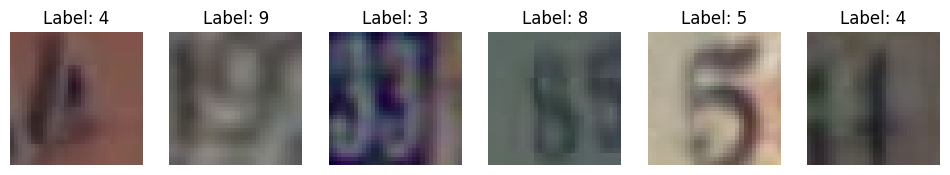

In [3]:
# Visualize some data
dataiter = iter(train_loader)
images, labels = dataiter.__next__()
fig, axes = plt.subplots(1, 6, figsize=(12,2))
for i in range(6):  
    img = images[i].numpy().transpose((1, 2, 0))
    img = img * np.array([0.1980, 0.2010, 0.1970]) + np.array([0.4377, 0.4438, 0.4728])  # unnormalize
    img = np.clip(img, 0, 1)
    axes[i].imshow(img)
    axes[i].set_title(f"Label: {labels[i].item()}")
    axes[i].axis('off')

## CNN Training

Now it is time to define our CNN. We use two convolution layers and two fully connected layers:

In [4]:
# Define a small CNN
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 8, kernel_size=3, padding=1) # (3 input channels, 8 output channels, 3x3 kernel, padding=1)
        self.pool1 = nn.MaxPool2d(2,2) # 2x2 max pooling with stride 2
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1) # (8 input channels, 16 output channels, 3x3 kernel, padding=1)
        self.pool2 = nn.MaxPool2d(2,2) # 2x2 max pooling with stride 2
        self.fc1   = nn.Linear(16*8*8, 64) # fully connected layer
        self.fc2   = nn.Linear(64, 10) # output layer for 10 classes

    def forward(self, x, return_feats=False):
        # Input: 3x32x32
        x = F.relu(self.conv1(x))
        # Output: 8x32x32
        f1 = self.pool1(x)
        # Output: 8x16x16
        x = F.relu(self.conv2(f1))
        # Output: 16x16x16
        f2 = self.pool2(x)
        # Output: 16x8x8
        x = torch.flatten(f2, 1)
        # Output: 16*8*8
        x = F.relu(self.fc1(x))
        # Output: 64
        logits = self.fc2(x) # CrossEntropyLoss expects raw logits
        # Output: 10
        if return_feats: return logits, f1, f2 # return features for visualization
        return logits

# Initialize model, loss function, and optimizer
model = SmallCNN().to(device)
criterion = nn.CrossEntropyLoss() 
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)


Let's train our model:

In [5]:
# Training and evaluation loop
def evaluate(model, loader, device):
    model.eval(); correct=total=0; loss_sum=0.0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device) 
            logits = model(images)
            loss = criterion(logits, labels)
            preds = logits.argmax(1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
            loss_sum += loss.item() * labels.size(0)
    return correct/max(1,total), loss_sum/max(1,total)

epochs = 5 # number of training epochs
train_hist, valid_hist = [], []

# Loop over epochs
for epoch in range(1, epochs+1): 
    model.train()
    run_loss=0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device) # move to device

        # Perform training step - one forward and backward pass
        optimizer.zero_grad() # zero the gradients
        logits = model(images) # forward pass
        loss = criterion(logits, labels) # compute loss
        loss.backward(); # backpropagate
        optimizer.step() # update weights

        run_loss += loss.item() # accumulate loss

    # Evaluate on training and validation sets
    train_acc, train_loss = evaluate(model, train_loader, device)
    valid_acc, valid_loss   = evaluate(model, valid_loader, device)
    train_hist.append((train_loss, train_acc))
    valid_hist.append((valid_loss, valid_acc))
    print(f"Epoch {epoch:02d}/{epochs} | Train loss {train_loss:.4f}, accuracy {train_acc*100:.2f}% | "
          f"Test loss {valid_loss:.4f}, accuracy {valid_acc*100:.2f}%")


Epoch 01/5 | Train loss 0.6173, accuracy 82.47% | Test loss 0.7055, accuracy 80.29%
Epoch 02/5 | Train loss 0.5061, accuracy 85.67% | Test loss 0.6179, accuracy 82.69%
Epoch 03/5 | Train loss 0.4450, accuracy 87.28% | Test loss 0.5590, accuracy 84.24%
Epoch 04/5 | Train loss 0.3958, accuracy 88.62% | Test loss 0.5301, accuracy 84.98%
Epoch 05/5 | Train loss 0.3720, accuracy 89.16% | Test loss 0.5114, accuracy 85.58%


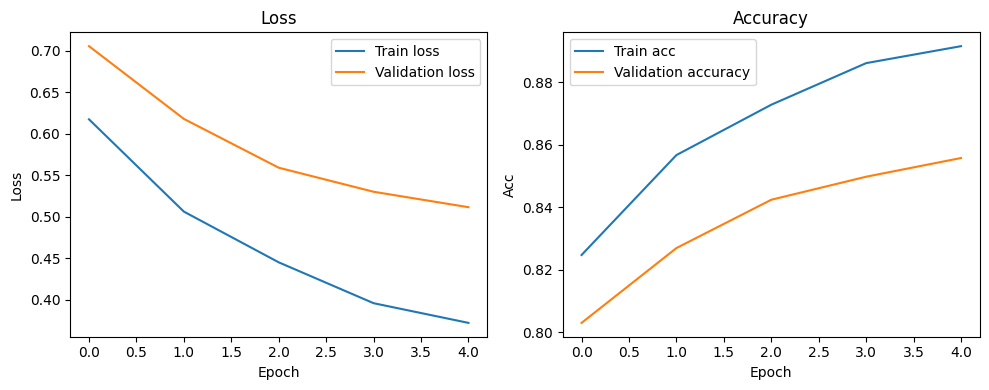

In [6]:
# Plot training loss and accuracy curves
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot([t[0] for t in train_hist], label='Train loss')
plt.plot([t[0] for t in valid_hist],  label='Validation loss')
plt.legend(); plt.title("Loss"); plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.subplot(1,2,2)
plt.plot([t[1] for t in train_hist], label='Train acc')
plt.plot([t[1] for t in valid_hist],  label='Validation accuracy')
plt.legend(); plt.title("Accuracy"); plt.xlabel("Epoch"); plt.ylabel("Acc")
plt.tight_layout(); plt.show()


The train and validation losses show some signs of overfitting (the large gap) - we could add some regularization for improvement. Both curves are decreasing properly. They have not fully converged yet, so we would usually keep training.

## Interpretation and Layer Visualization

Now let's take a glimpse into the black box with a single test image:

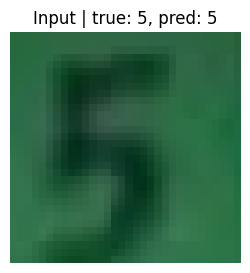

In [7]:
# One test image + feature maps
model.eval()
images, labels = next(iter(valid_loader))
img = images[0:1].to(device); label = labels[0].item()
with torch.no_grad():
    logits, f1, f2 = model(img, return_feats=True)
    pred = logits.argmax(1).item()

# Denormalize for display
mean = torch.tensor([0.4377, 0.4438, 0.4728], device=device).view(1,3,1,1)
std  = torch.tensor([0.1980, 0.2010, 0.1970], device=device).view(1,3,1,1)
img_denorm = img * std + mean
img_np = img_denorm[0].detach().cpu().permute(1,2,0).numpy(); img_np = np.clip(img_np, 0, 1)

plt.figure(figsize=(3,3)); plt.imshow(img_np); plt.title(f"Input | true: {label}, pred: {pred}")
plt.axis('off'); plt.show()


We start by visualizing the feature maps in the first convolution layer:

In [8]:
# Visualization helpers
import math
def plot_feature_maps_grid(feat, title_prefix="Feature map", max_maps=16):
    feat_np = feat[0].detach().cpu().numpy()
    C, H, W = feat_np.shape; n = min(C, max_maps)
    cols = int(math.sqrt(n) + 0.999); rows = int(math.ceil(n / cols))
    plt.figure(figsize=(2*cols, 2*rows))
    for i in range(n):
        plt.subplot(rows, cols, i+1)
        fm = feat_np[i]; fm = (fm - fm.min()) / (fm.max() - fm.min() + 1e-8)
        plt.imshow(fm, cmap='gray'); plt.title(f"{title_prefix} {i}"); plt.axis('off')
    plt.tight_layout(); plt.show()

f1 shape: torch.Size([1, 8, 16, 16])
f2 shape: torch.Size([1, 16, 8, 8])


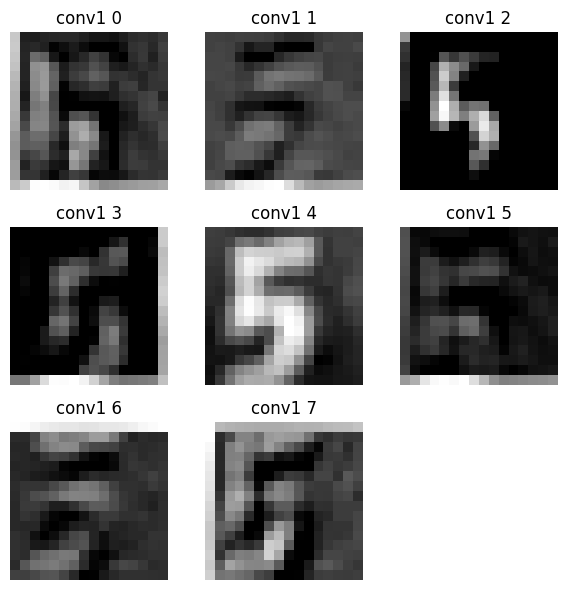

In [9]:
# check f1 and f2 shape 
print('f1 shape:', f1.shape)
print('f2 shape:', f2.shape)

# plot conv1 maps
plot_feature_maps_grid(f1, title_prefix="conv1", max_maps=8)

And the second conv layer - note that the spatial resolution is decreasing, whereas the channels (the numbers of feature maps) are increasing: 

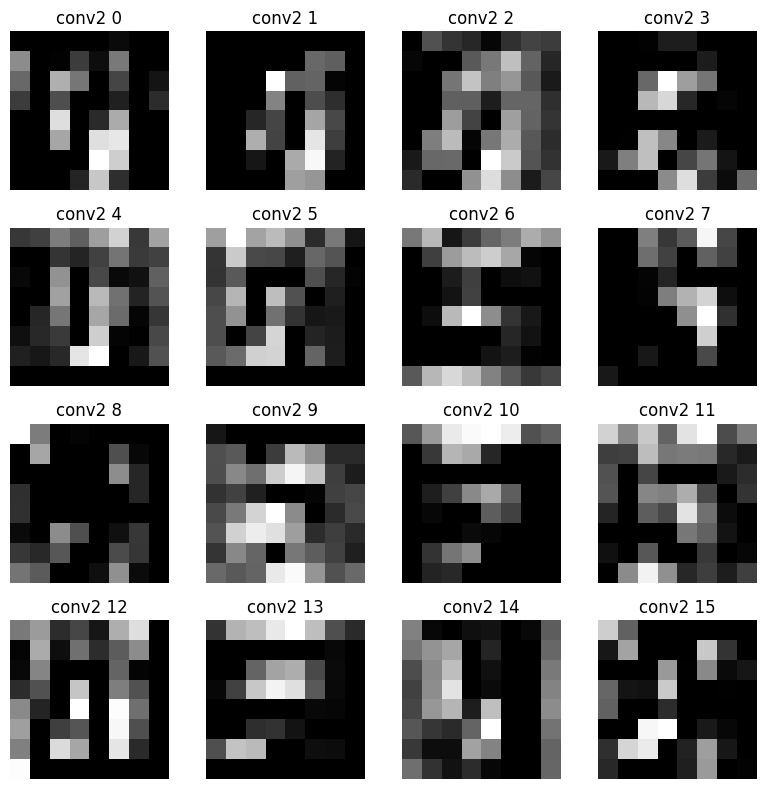

In [10]:
# conv2 maps — grid
plot_feature_maps_grid(f2, title_prefix="conv2", max_maps=16)

Now let's visualize the learned filter weights to see what each filter responds to:

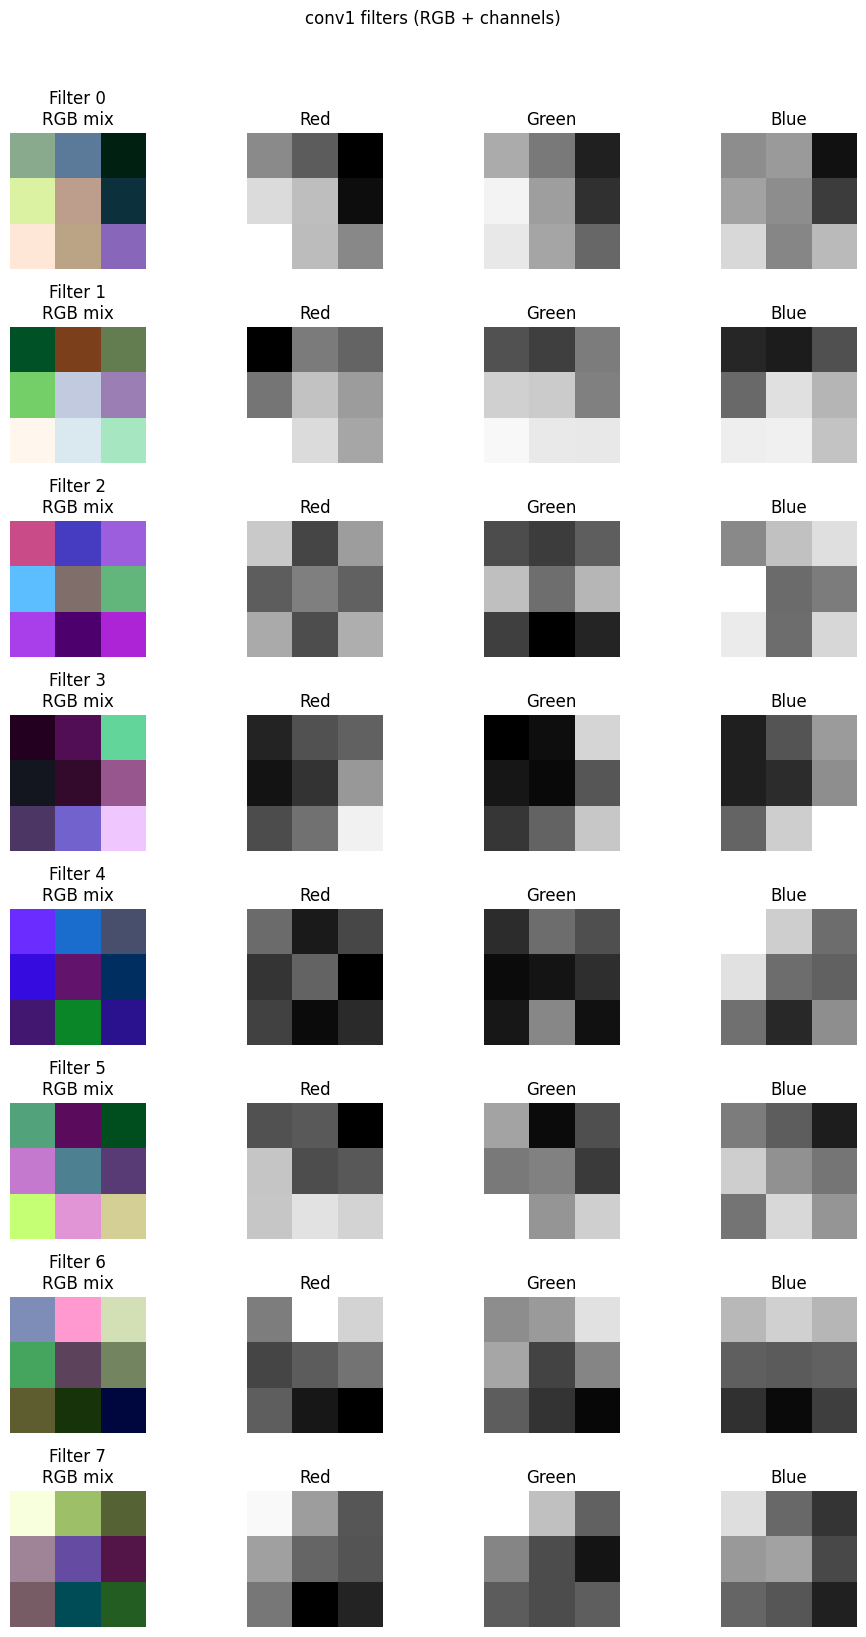

In [11]:
# Visualize first-layer conv filters by channel (R/G/B separately)

w = model.conv1.weight.detach().cpu().numpy()  # [n_filters, 3, 3, 3]
n_filters = w.shape[0]
cols = 4   # 1x RGB + 3x channels
rows = n_filters

plt.figure(figsize=(2.5 * cols, 2 * rows))

for i in range(n_filters):
    k = w[i]  # [3,3,3]
    k_min, k_max = k.min(), k.max()
    k_norm = (k - k_min) / (k_max - k_min + 1e-8)
    k_rgb = np.transpose(k_norm, (1, 2, 0))

    # Combined RGB
    plt.subplot(rows, cols, i * cols + 1)
    plt.imshow(k_rgb)
    plt.title(f"Filter {i}\nRGB mix")
    plt.axis("off")

    # Individual channels
    for c, name in enumerate(["Red", "Green", "Blue"], start=1):
        plt.subplot(rows, cols, i * cols + c + 1)
        plt.imshow(k_norm[c-1], cmap="gray", vmin=0, vmax=1)
        plt.title(name)
        plt.axis("off")

plt.suptitle("conv1 filters (RGB + channels)", y=1.02)
plt.tight_layout()
plt.show()


It looks like filter 3 has leared to detect transitions from dark to light (left to right). Let's try it out on a synthetic image and analyse the result!

In [12]:
def visualize_cnn_features(model, img, device='cpu', n_maps=8, title='Input image'):
    """
    Apply a CNN to an input image and visualize the first-layer feature maps.

    Args:
        model: CNN model that returns (output, feat1, feat2, ...) when called with return_feats=True
        img: torch.Tensor or np.ndarray, shape (3,H,W) or (1,3,H,W)
        device: 'cpu' or 'cuda'
        n_maps: number of feature maps to display
        title: title for input image plot
    """

    # Ensure shape (1,3,H,W)
    if img.ndim == 3:
        img = img.unsqueeze(0)
    img = img.to(device, dtype=torch.float32)

    # Forward pass
    with torch.no_grad():
        outputs = model(img, return_feats=True)
        if isinstance(outputs, tuple):
            _, f1, f2 = outputs
        else:
            raise ValueError("Model must return (out, feat1, feat2, ...) with return_feats=True")

    # === Plot input image ===
    fig, ax = plt.subplots(figsize=(3,3))
    ax.imshow(img[0].permute(1,2,0).cpu(), vmin=0, vmax=1)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor('black')
        spine.set_linewidth(1)
    fig.suptitle(f"Input image – {title}", fontsize=12)
    plt.show()

    # === Plot conv1 feature maps ===
    f1_np = f1[0].cpu().numpy()
    n_maps = min(n_maps, f1_np.shape[0])
    cols = 4
    rows = math.ceil(n_maps / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(2*cols, 2*rows))

    # Flatten 2D axes array for easy indexing
    axes = axes.flatten()

    for i in range(n_maps):
        fm = f1_np[i]
        fm = (fm - fm.min()) / (fm.max() - fm.min() + 1e-8)
        ax = axes[i]
        ax.imshow(fm, cmap='gray')
        ax.set_title(f"FM {i}", fontsize=10)
        ax.set_xticks([]); ax.set_yticks([])

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_edgecolor('black')
            spine.set_linewidth(1)

    # Turn off unused subplots
    for j in range(n_maps, len(axes)):
        axes[j].axis('off')

    fig.suptitle(f"conv1 activations – {title}", fontsize=12)
    plt.tight_layout()
    plt.show()


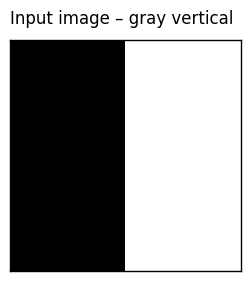

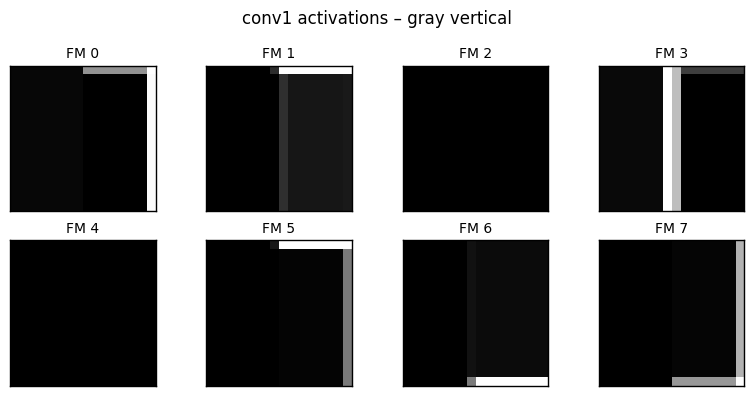

In [13]:
# Generate synthetic test patterns with sharp intensity or color transitions
size = 32
img = torch.zeros(3, size, size)
img[:, :, 32//2:] = 1.0
visualize_cnn_features(model, img, device=device, title='gray vertical')

Our suggestion was right, filter 3 responds most strongly to the vertical edge! Let's see which filter responds to horizontal edges (can you guess from the filter display above?)

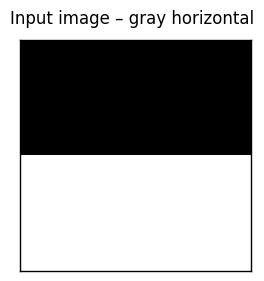

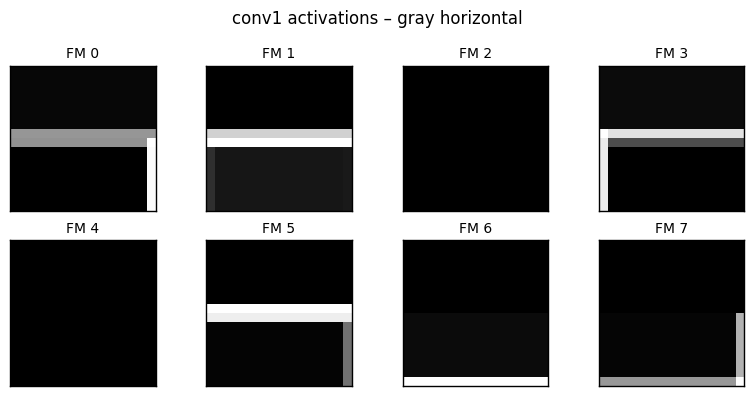

In [14]:
# Generate synthetic test patterns with sharp intensity or color transitions
img = torch.zeros(3, size, size)
img[:, size//2:, :] = 1.0
visualize_cnn_features(model, img, device=device, title='gray horizontal')

We can also find out that filter 6 has learned to detect diagonals like this: 

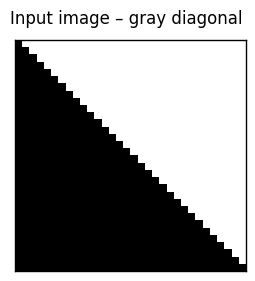

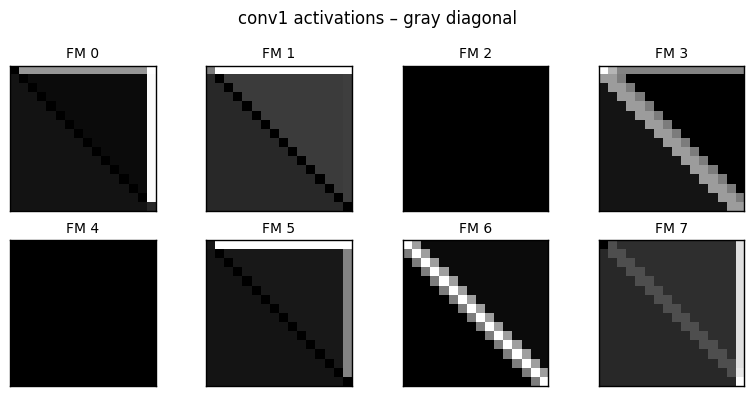

In [15]:
# Generate synthetic test patterns with sharp intensity or color transitions
img = torch.zeros(3, size, size)
for i in range(size):
    for j in range(size):
        if j > i:
            img[:, i, j] = 1.0
visualize_cnn_features(model, img, device=device, title='gray diagonal')

Some filters have also learned to react to color transitions:

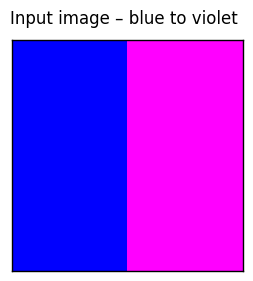

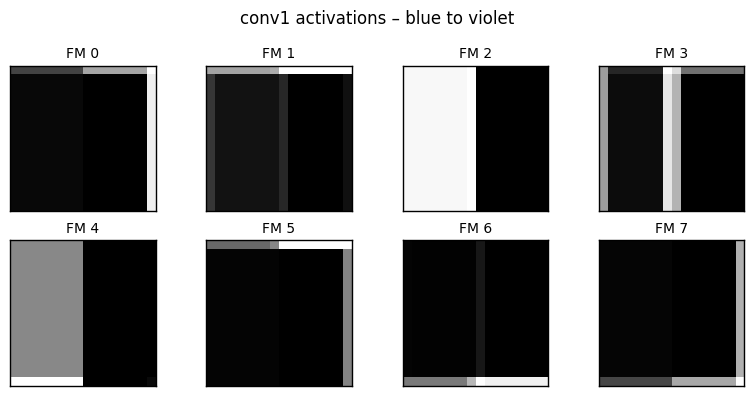

In [16]:
# Generate synthetic test patterns with sharp intensity or color transitions
img = torch.zeros(3, size, size)
img[2, :, :size//2] = 1.0            # blue
img[0, :, size//2:] = 1.0; img[2, :, size//2:] = 1.0  # violet
visualize_cnn_features(model, img, device=device, title='blue to violet')

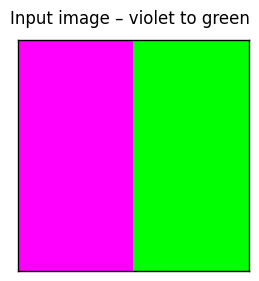

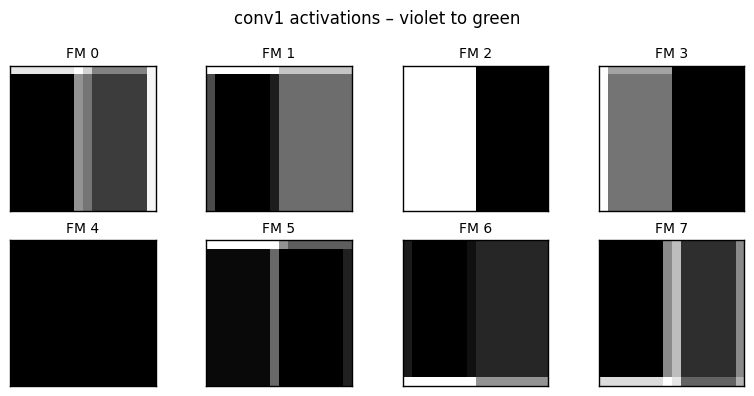

In [17]:
# Generate synthetic test patterns with sharp intensity or color transitions
img = torch.zeros(3, size, size)
img[0, :, :size//2] = 1.0; img[2, :, :size//2] = 1.0  # violet
img[1, :, size//2:] = 1.0                            # green
visualize_cnn_features(model, img, device=device, title='violet to green')

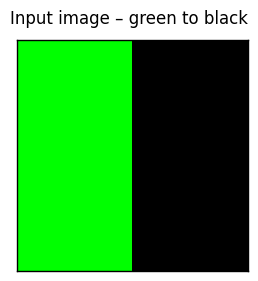

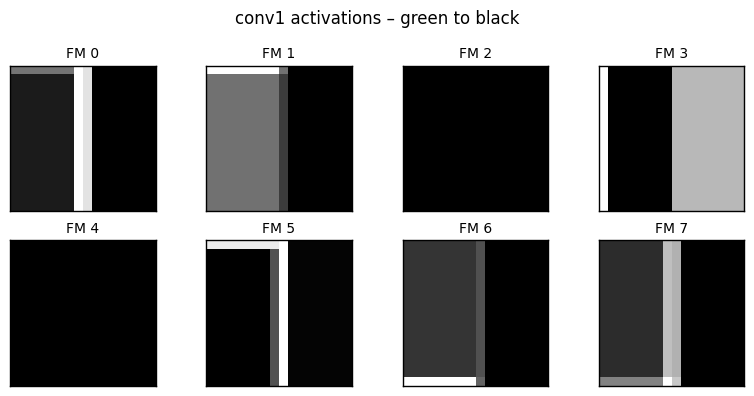

In [18]:
# Generate synthetic test patterns with sharp intensity or color transitions
img = torch.zeros(3, size, size)
img[1, :, :size//2] = 1.0
visualize_cnn_features(model, img, device=device, title='green to black')

To sum it up, convolution layers usually decrease spatial resolution while increasing depth. First layer filters learn to detect basic patterns like edges, stripes, color transitions. Deeper layers detect more and more complex patterns, object parts and finally full objects.